# DARLIN single-cell downstream analysis — lung & liver

Integrates DARLIN lineage barcodes (all three loci: CC/cCARLIN, TC/Tigre_2022_v2, RC/Rosa_v2)
with matched 10x Chromium v3 gene expression data.

**Data source:** Li et al., Cell 2023 — DARLIN lineage tracing mouse, hematopoietic LK (Lin−Kit+) cells from lung and liver.

**Prerequisites:** Run `Single-cell-tutorial-Part_1_clone_calling.ipynb` first to produce
`df_sc_data_{read_cutoff}.csv` at `root_path`. That notebook handles multi-locus clone assignment
using `mosaic.DARLIN.assign_clone_id_by_integrating_locus()` and saves `joint_clone_id` per cell.

**Pipeline outputs used:**
- GEX: `data/cellranger_gex/{tissue}/outs/filtered_feature_bc_matrix/`
- Lineage: `df_sc_data_{read_cutoff}.csv` (produced by Part 1, contains `joint_clone_id`)

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as ssp
import scanpy as sc
import cospar as cs
import seaborn as sns
from matplotlib import pyplot as plt, rcParams

cs.logging.print_version()
cs.settings.verbosity = 0
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

Running cospar 0.4.1 (python 3.11.14) on 2026-03-03 07:59.
 Your version: 		 0.4.1 
Latest version: 	 0.5.0


In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
# Root of the snakemake_DARLIN repo (where df_sc_data_{read_cutoff}.csv is saved by Part 1)
root_path = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
# Or set explicitly:
# root_path = '/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN'

data_dir   = os.path.join(root_path, 'data')
meta_dir   = os.path.join(root_path, 'metadata')

# Which tissues to analyse (must exist in both GEX cellranger output and DARLIN output)
tissues = ['lung', 'liver', 'spleen', 'LeftLeg']

# DARLIN pipeline settings — must match what Part 1 was run with
read_cutoff  = 3   # results_cutoff_override_{read_cutoff}
max_rep_N    = 1   # allele must appear in ≤ this many mouse samples (mirrors Part 2 tutorial)

# Output
figure_path = 'DARLIN_lungliver_figs'
os.makedirs(figure_path, exist_ok=True)
os.makedirs('data', exist_ok=True)
sc.settings.figdir  = figure_path
cs.settings.figure_path = figure_path

# Plot settings
cs.settings.set_figure_params(format='pdf', figsize=[4, 3.5], dpi=100,
                               fontsize=14, pointsize=3, dpi_save=300)
rcParams['axes.grid'] = False

## 1. Load metadata — map tissue names ↔ SRR accessions

In [3]:
gex_meta    = pd.read_csv(os.path.join(meta_dir, '10x_gex_metadata.csv'))
darlin_meta = pd.read_csv(os.path.join(meta_dir, 'metadata.csv'))

# GEX: source_name → SRR (one row per tissue, v3 chemistry)
gex_run_map = dict(zip(
    gex_meta['source_name'].str.strip(),
    gex_meta['Run'].str.strip()
))

# DARLIN: source_name → list of SRR (may have multiple loci per tissue)
darlin_run_map = (
    darlin_meta.groupby('source_name')['Run'].apply(list).to_dict()
)

print('GEX run map:', {t: gex_run_map.get(t) for t in tissues})
print('DARLIN run map:', {t: darlin_run_map.get(t) for t in tissues})

GEX run map: {'lung': 'SRR23027541', 'liver': 'SRR23027542', 'spleen': 'SRR23027540', 'LeftLeg': 'SRR23027543'}
DARLIN run map: {'lung': ['SRR23027768', 'SRR23027769', 'SRR23027770'], 'liver': ['SRR23027765', 'SRR23027766', 'SRR23027767'], 'spleen': ['SRR23027774', 'SRR23027775', 'SRR23027776'], 'LeftLeg': ['SRR23027762', 'SRR23027763', 'SRR23027764']}


## 2. Load & preprocess GEX data (per tissue)

In [4]:
def load_and_preprocess_gex(tissue, data_dir, min_genes=200, max_pct_mt=20,
                             n_top_genes=3000, n_pcs=30, n_neighbors=15):
    """Load cellranger output and run standard scanpy preprocessing."""
    mtx_path = os.path.join(data_dir, 'cellranger_gex', tissue,
                            'outs', 'filtered_feature_bc_matrix')
    adata = sc.read_10x_mtx(mtx_path, var_names='gene_symbols', cache=True)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adata.obs['tissue'] = tissue

    # QC
    adata.var['mt'] = adata.var_names.str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None,
                               log1p=False, inplace=True)
    before = adata.n_obs
    adata = adata[
        (adata.obs['n_genes_by_counts'] >= min_genes) &
        (adata.obs['pct_counts_mt']     <= max_pct_mt)
    ].copy()
    print(f'{tissue}: {before} → {adata.n_obs} cells after QC')

    # Normalise, log, HVG
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.raw = adata
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, batch_key=None)

    # PCA, neighbours, UMAP
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, use_highly_variable=True)
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

    # cospar expects X_emb
    adata.obsm['X_emb'] = adata.obsm['X_umap']
    return adata

adatas_gex = {}
for tissue in tissues:
    mtx_path = os.path.join(data_dir, 'cellranger_gex', tissue,
                            'outs', 'filtered_feature_bc_matrix')
    if not os.path.exists(mtx_path):
        print(f'[skip] GEX output not found for {tissue}: {mtx_path}')
        continue
    adatas_gex[tissue] = load_and_preprocess_gex(tissue, data_dir)

lung: 1956 → 1604 cells after QC


/pub/kstachel/.conda/envs/darlin/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/pub/kstachel/.conda/envs/darlin/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/pub/kstachel/.conda/envs/darlin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1692824/2653504958.py:33: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaul

liver: 5311 → 5200 cells after QC


/pub/kstachel/.conda/envs/darlin/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/pub/kstachel/.conda/envs/darlin/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


spleen: 1965 → 1909 cells after QC


/pub/kstachel/.conda/envs/darlin/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/pub/kstachel/.conda/envs/darlin/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


LeftLeg: 3105 → 3086 cells after QC


/pub/kstachel/.conda/envs/darlin/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/pub/kstachel/.conda/envs/darlin/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


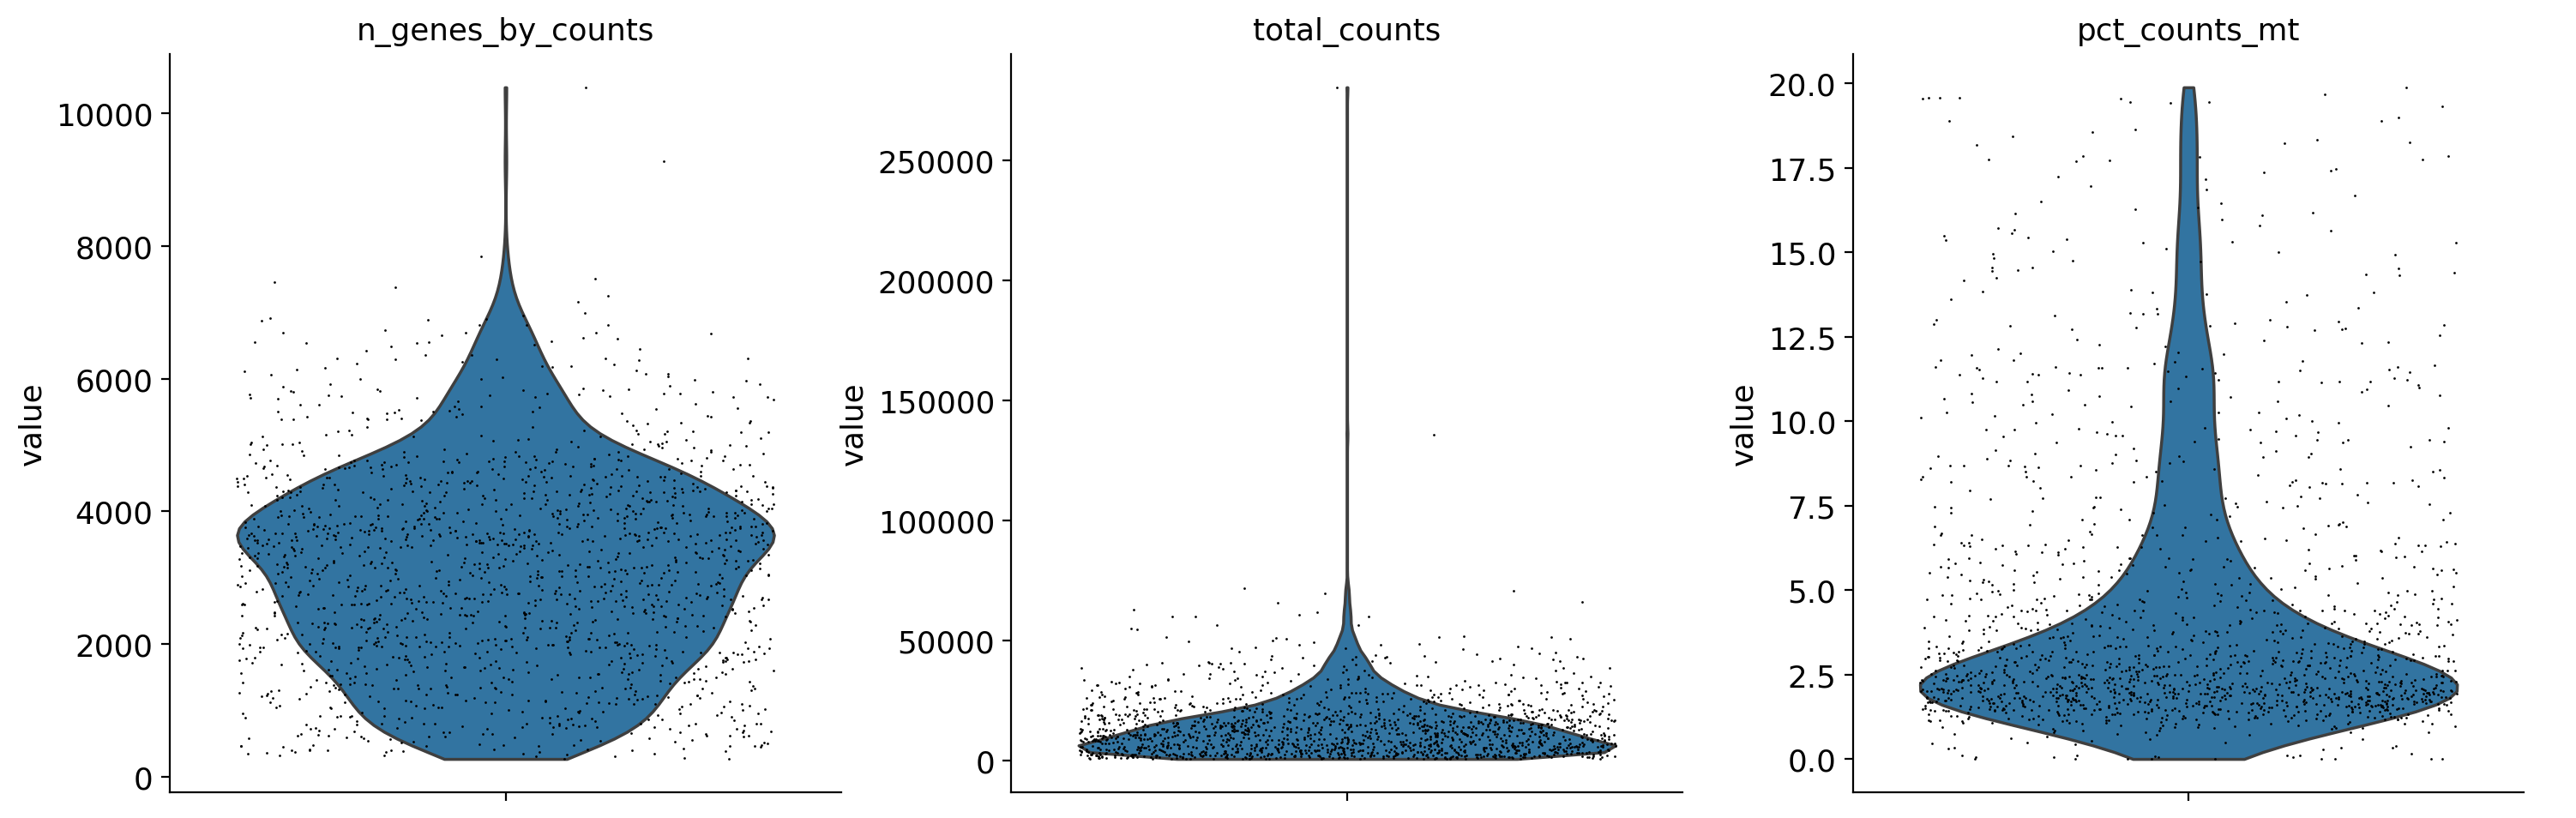

In [5]:
# Quick QC overview for first available tissue
tissue0 = list(adatas_gex.keys())[0]
adata0  = adatas_gex[tissue0]
sc.pl.violin(adata0, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

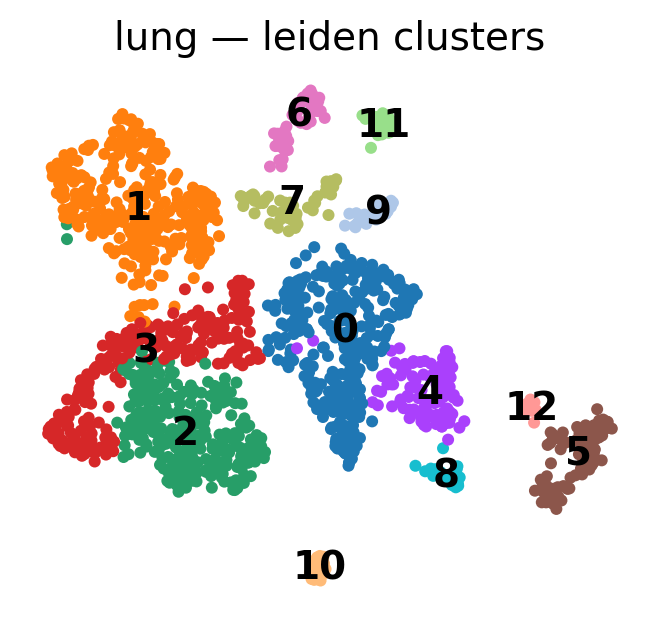

In [6]:
sc.pl.umap(adata0, color='leiden', legend_loc='on data',
           title=f'{tissue0} — leiden clusters', frameon=False)

## 3. Cell type annotation

LK (Lin−Kit+) cells are enriched for HSPCs.  
Annotate with canonical mouse HSPC marker genes.

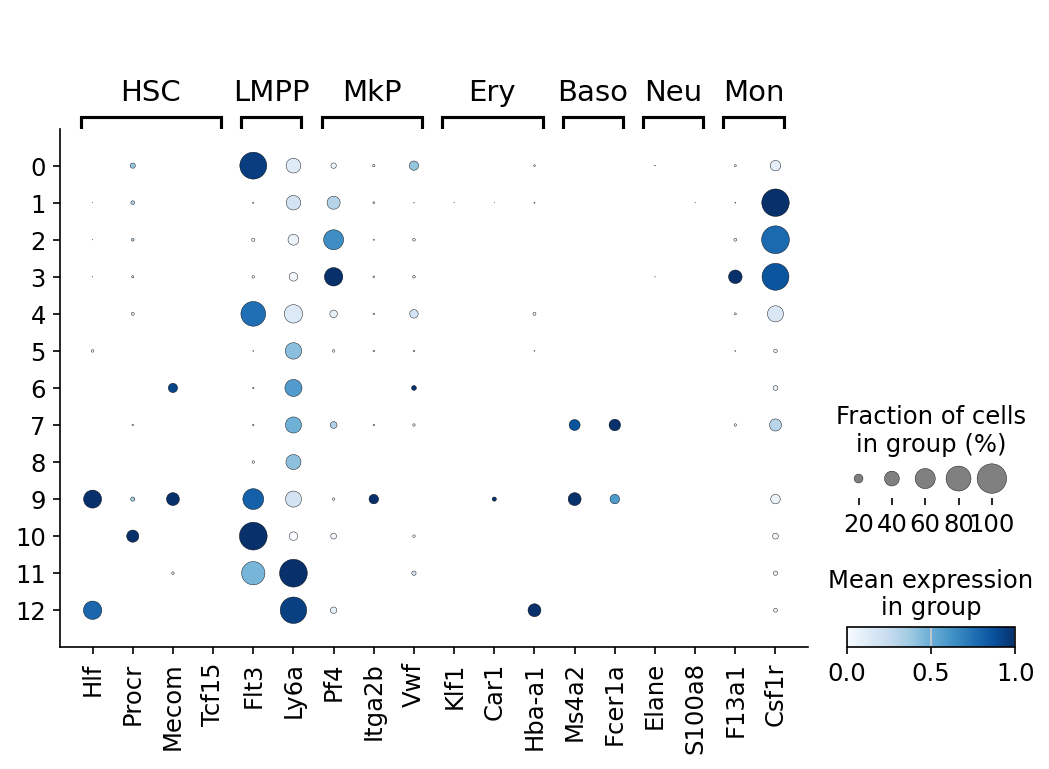

In [7]:
# Mouse HSPC marker genes
celltype_genes = {
    'HSC'  : ['Hlf', 'Procr', 'Mecom', 'Tcf15'],
    'LMPP' : ['Flt3', 'Ly6a'],
    'MkP'  : ['Pf4', 'Itga2b', 'Vwf'],
    'Ery'  : ['Klf1', 'Car1', 'Hba-a1'],
    'Baso' : ['Ms4a2', 'Fcer1a'],
    'Neu'  : ['Elane', 'S100a8'],
    'Mon'  : ['F13a1', 'Csf1r'],
}

# Plot marker genes
sc.settings.set_figure_params(dpi=75)
sc.pl.dotplot(adata0, celltype_genes, groupby='leiden',
              dendrogram=False, standard_scale='var', cmap='Blues')

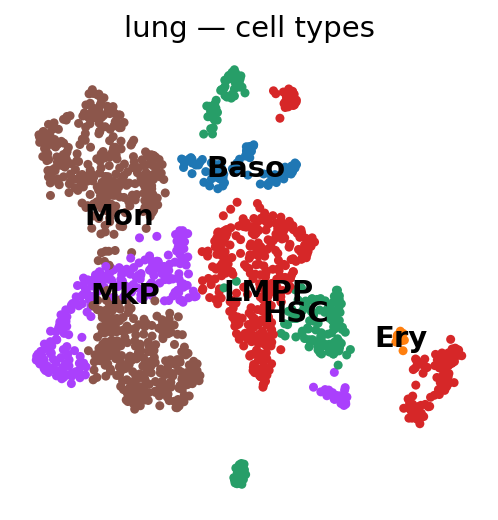

In [8]:
# ── Manual cluster→cell_type mapping ──────────────────────────────────────────
# Inspect the dotplot above and fill in the mapping for each leiden cluster.
# Example (adjust after inspecting the dotplot):
cluster_to_celltype = {
    '0': 'LMPP',
    '1': 'Mon',
    '2': 'Mon',
    '3': 'MkP',
    '4': 'HSC',
    '5': 'LMPP',
    '6': 'HSC',
    '7': 'Baso',
    '8': 'MkP',
    '9': 'Baso',
    '10': 'HSC',
    '11': 'LMPP',
    '12': 'Ery',
}

if cluster_to_celltype:
    for adata in adatas_gex.values():
        adata.obs['cell_type'] = (
            adata.obs['leiden'].astype(str).map(cluster_to_celltype).fillna('Unknown')
        )
    sc.pl.umap(adata0, color='cell_type', legend_loc='on data', frameon=False,
               title=f'{tissue0} — cell types')
else:
    print('Fill in cluster_to_celltype above after inspecting the dotplot.')
    for adata in adatas_gex.values():
        adata.obs['cell_type'] = adata.obs['leiden'].astype(str)

## 4. Load DARLIN clone data (multi-locus joint clone assignments)

Loads `df_sc_data_{read_cutoff}.csv` produced by `Single-cell-tutorial-Part_1_clone_calling.ipynb`.
That file already contains the multi-locus `joint_clone_id` (CC + TC + RC integrated) and
`joint_prob` (confidence of the assignment). The `sample` column equals the tissue source name
(`lung`/`liver`) after SRR→source_name remapping done in Part 1.

In [9]:
sc_data_path = os.path.join(root_path, f'data/df_sc_data_{read_cutoff}.csv')
df_sc_data = pd.read_csv(sc_data_path)
print('df_sc_data shape:', df_sc_data.shape)
print('Columns:', df_sc_data.columns.tolist())
print('Samples:', df_sc_data['sample'].unique())
df_sc_data.head(3)

df_sc_data shape: (35703, 21)
Columns: ['allele', 'UMI_count', 'sample', 'mouse', 'cell_bc', 'CB_N', 'clone_id', 'CARLIN_length', 'clone_size', 'normalized_count', 'sample_count', 'invalid_alleles', 'locus', 'library', 'plate_ID', 'RNA_id', 'lineage', 'joint_clone_id_tmp', 'joint_clone_id', 'joint_prob', 'joint_allele_num']
Samples: ['LeftLeg' 'liver' 'lung' 'skull' 'spleen']


,allele,UMI_count,sample,mouse,cell_bc,CB_N,clone_id,CARLIN_length,clone_size,normalized_count,...,invalid_alleles,locus,library,plate_ID,RNA_id,lineage,joint_clone_id_tmp,joint_clone_id,joint_prob,joint_allele_num
0,TA_[],773,LeftLeg,LeftLeg,AAACCCACATAGTCGT,773,TA_TCGCCGGAGTCGAGACGCTGACGATATGGAGTCGACACGACTC...,273,773,1.000000,...,True,TA,LeftLeg,LeftLeg,LeftLeg_RNA_AAACCCACATAGTCGT,LeftLeg,NaN,NaN,NaN,NaN
1,"TA_132_133delinsAAA,266_267insG",6,LeftLeg,LeftLeg,AAACCCACATGCCGGT,6,TA_TCGCCGGAGTCGAGACGCTGACGATATGGAGTCGACACGACTC...,275,6,0.000000,...,0,TA,LeftLeg,LeftLeg,LeftLeg_RNA_AAACCCACATGCCGGT,LeftLeg,"nan@nan@TA_132_133delinsAAA,266_267insG","CA_22_23insA,77_184delinsAAA@TA_132_133delinsA...",0.0,2.0
2,TA_131_132insGA,439,LeftLeg,LeftLeg,AAACCCATCTTCGGTC,439,TA_TCGCCGGAGTCGAGACGCTGACGATATGGAGTCGACACGACTC...,275,439,0.000013,...,True,TA,LeftLeg,LeftLeg,LeftLeg_RNA_AAACCCATCTTCGGTC,LeftLeg,NaN,NaN,NaN,NaN


In [10]:
# Filter to each tissue.
# Part 1 remaps SRR accessions → source_name before saving df_sc_data,
# so the 'sample' column equals the tissue name ('lung', 'liver').
darlin_per_cell = {}
for tissue in tissues:
    df_tissue = df_sc_data[df_sc_data['sample'] == tissue].copy()
    if len(df_tissue) == 0:
        print(f'[skip] No DARLIN data found for tissue={tissue!r} '
              f'(check that Part 1 was run with source_name remapping)')
        continue
    darlin_per_cell[tissue] = df_tissue
    n_cells  = df_tissue['cell_bc'].nunique()
    n_clones = df_tissue['joint_clone_id'].dropna().nunique()
    n_loci   = df_tissue['locus'].nunique() if 'locus' in df_tissue.columns else '?'
    print(f'{tissue}: {len(df_tissue)} locus×cell rows, {n_cells} unique barcodes, '
          f'{n_clones} joint clones, {n_loci} loci')

lung: 12948 locus×cell rows, 10333 unique barcodes, 1946 joint clones, 3 loci
liver: 2191 locus×cell rows, 1628 unique barcodes, 535 joint clones, 3 loci
spleen: 3921 locus×cell rows, 3006 unique barcodes, 768 joint clones, 3 loci
LeftLeg: 5990 locus×cell rows, 4384 unique barcodes, 1066 joint clones, 3 loci


In [11]:
# Quality filter — mirrors Part 2 tutorial exactly:
#   - keep only cells that received a joint clone assignment (joint_prob not NaN)
#   - exclude alleles seen in more than max_rep_N mouse samples
for tissue in list(darlin_per_cell.keys()):
    df = darlin_per_cell[tissue]
    before = df['cell_bc'].nunique()
    df_hq = df[
        df['joint_prob'].notna() &
        (df['sample_count'] <= max_rep_N)
    ].copy()
    darlin_per_cell[tissue] = df_hq
    after = df_hq['cell_bc'].nunique()
    print(f'{tissue}: {before} → {after} cells after quality filter '
          f'(joint_prob not NaN, sample_count ≤ {max_rep_N})')

lung: 10333 → 5536 cells after quality filter (joint_prob not NaN, sample_count ≤ 1)
liver: 1628 → 961 cells after quality filter (joint_prob not NaN, sample_count ≤ 1)
spleen: 3006 → 1733 cells after quality filter (joint_prob not NaN, sample_count ≤ 1)
LeftLeg: 4384 → 2656 cells after quality filter (joint_prob not NaN, sample_count ≤ 1)


## 5. Integrate lineage with GEX (per tissue)

In [12]:
def integrate_lineage(adata, df_darlin_hq):
    """
    Match DARLIN barcodes to GEX barcodes and build X_clone.

    df_darlin_hq is long-format (one row per locus×cell) from df_sc_data_{cutoff}.csv.
    Uses joint_clone_id (multi-locus integrated) and cell_bc with '-1' suffix to
    match cellranger barcodes.
    """
    df = df_darlin_hq.copy()
    # cellranger appends '-1' to raw 16-nt barcodes
    df['RNA_id'] = df['cell_bc'].str.strip() + '-1'

    # Keep only cells present in the GEX adata
    df_matched = df[df['RNA_id'].isin(adata.obs_names)].copy()

    # Deduplicate: one (cell, clone) pair — long-format has one row per locus per cell
    df_matched_dedup = (
        df_matched[['RNA_id', 'joint_clone_id']]
        .drop_duplicates()
    )

    n_cells_with_lineage = df_matched_dedup['RNA_id'].nunique()
    frac = n_cells_with_lineage / adata.n_obs
    print(f'  {n_cells_with_lineage}/{adata.n_obs} GEX cells have DARLIN data '
          f'({100*frac:.1f}%)')

    # Build X_clone using cospar (cell × clone sparse matrix)
    cs.pp.get_X_clone(adata, df_matched_dedup['RNA_id'], df_matched_dedup['joint_clone_id'])
    cs.pp.initialize_adata_object(adata)
    return adata, df_matched_dedup


adatas_integrated = {}
for tissue in tissues:
    if tissue not in adatas_gex or tissue not in darlin_per_cell:
        print(f'[skip] {tissue}: missing GEX or DARLIN data')
        continue
    print(f'Integrating {tissue}...')
    # Quick Debugging Snippet
    sample_bc_df = darlin_per_cell[tissue]['cell_bc'].iloc[0].strip() + '-1'
    sample_bc_adata = adatas_gex[tissue].obs_names[0]

    print(f"\n[Debug {tissue}]")
    print(f"DF Sample:    '{sample_bc_df}'")
    print(f"Adata Sample: '{sample_bc_adata}'")
    print(f"Lengths:      DF({len(sample_bc_df)}) vs Adata({len(sample_bc_adata)})")
    adata_int, _ = integrate_lineage(
        adatas_gex[tissue].copy(),
        darlin_per_cell[tissue]
    )
    adatas_integrated[tissue] = adata_int
    print(adata_int)

Integrating lung...

[Debug lung]
DF Sample:    'AAACCCAGTGCGAACA-1'
Adata Sample: 'AAACGAAAGCTACAAA-1'
Lengths:      DF(18) vs Adata(18)
  2/1604 GEX cells have DARLIN data (0.1%)


100%|██████████| 2/2 [00:00<00:00, 26715.31it/s]

AnnData object with n_obs × n_vars = 1604 × 27998
    obs: 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'time_info', 'state_info'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'clone_id', 'data_des', 'time_ordering', 'clonal_time_points'
    obsm: 'X_pca', 'X_umap', 'X_emb', 'X_clone'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Integrating liver...

[Debug liver]
DF Sample:    'AAAGAACAGAAATGGG-1'
Adata Sample: 'AAACCCACAGTAGATA-1'
Lengths:      DF(18) vs Adata(18)


  1/5200 GEX cells have DARLIN data (0.0%)


100%|██████████| 1/1 [00:00<00:00, 9576.04it/s]

...

100%|██████████| 961/961 [00:00<00:00, 1329833.77it/s]

AnnData object with n_obs × n_vars = 1909 × 27998
    obs: 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'time_info', 'state_info'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'clone_id', 'data_des', 'time_ordering', 'clonal_time_points'
    obsm: 'X_pca', 'X_umap', 'X_emb', 'X_clone'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Integrating LeftLeg...

[Debug LeftLeg]
DF Sample:    'AAACCCACATGCCGGT-1'
Adata Sample: 'AAACCCACAGGCCTGT-1'
Lengths:      DF(18) vs Adata(18)


  1674/3086 GEX cells have DARLIN data (54.2%)


100%|██████████| 1674/1674 [00:00<00:00, 1487556.12it/s]

AnnData object with n_obs × n_vars = 3086 × 27998
    obs: 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'time_info', 'state_info'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'clone_id', 'data_des', 'time_ordering', 'clonal_time_points'
    obsm: 'X_pca', 'X_umap', 'X_emb', 'X_clone'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## 6. Assign time info for CoSpar

HSPCs → t0 (initial progenitors), committed cells → t1.

In [13]:
# Adjust this mapping after cell type annotation is complete
time_map = {
    'HSC' : 't0',
    'LMPP': 't0',
    'MkP' : 't1',
    'Ery' : 't1',
    'Baso': 't1',
    'Neu' : 't1',
    'Mon' : 't1',
    'Unknown': 't1',
}

for tissue, adata in adatas_integrated.items():
    adata.obs['state_info'] = adata.obs['cell_type'].astype(str)
    adata.obs['time_info']  = adata.obs['cell_type'].map(time_map).fillna('t1')
    cs.pp.initialize_adata_object(adata)
    print(f'{tissue}: {adata.obs["time_info"].value_counts().to_dict()}')

lung: {'t1': 964, 't0': 640}
liver: {'t1': 2676, 't0': 2524}
spleen: {'t0': 956, 't1': 953}
LeftLeg: {'t1': 1613, 't0': 1473}


## 7. Visualise — pick a tissue for detailed analysis

Analysing: spleen


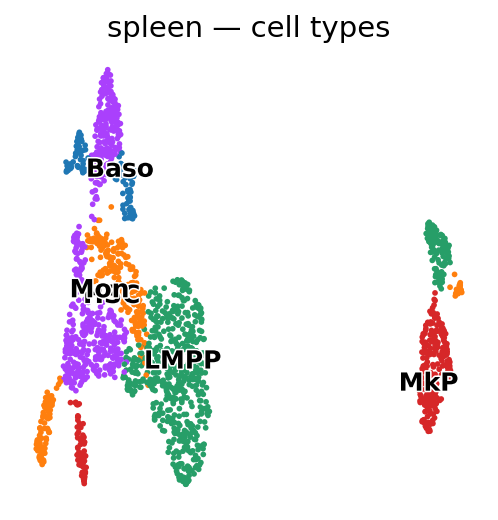

In [14]:
# Focus on the first available integrated tissue
tissue_focus = list(adatas_integrated.keys())[2]
adata = adatas_integrated[tissue_focus]
print(f'Analysing: {tissue_focus}')

sc.pl.umap(adata, color='cell_type', legend_loc='on data',
           legend_fontsize=12, legend_fontoutline=1.5, s=30,
           frameon=False, title=f'{tissue_focus} — cell types',
           save=f'_{tissue_focus}_celltypes')

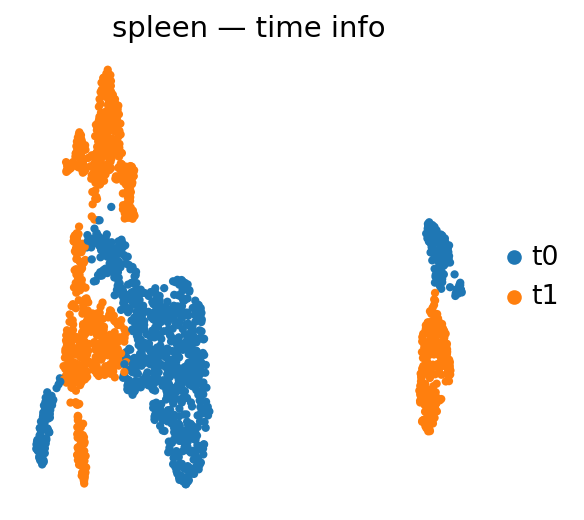

In [15]:
sc.pl.umap(adata, color='time_info', frameon=False,
           title=f'{tissue_focus} — time info',
           save=f'_{tissue_focus}_time_info')

## 8. Clone statistics

580 clones total


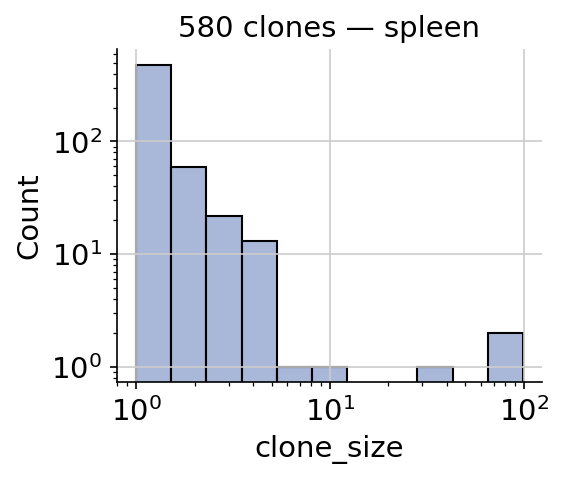

In [16]:
df_clone = cs.tl.clone_statistics(adata, joint_variable='state_info')
cs.tl.add_clone_id_for_each_cell(adata)

n_clones = int(np.sum((adata.obsm['X_clone'].sum(0) > 0).A.flatten()))
print(f'{n_clones} clones total')

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.histplot(df_clone['clone_size'], log_scale=True, color='#8da0cb')
plt.yscale('log')
plt.title(f'{n_clones} clones — {tissue_focus}')
plt.tight_layout()
plt.savefig(f'{figure_path}/{tissue_focus}_clone_distribution.pdf')

/tmp/ipykernel_1692824/181600242.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('cell_type').size().reset_index(name='count')


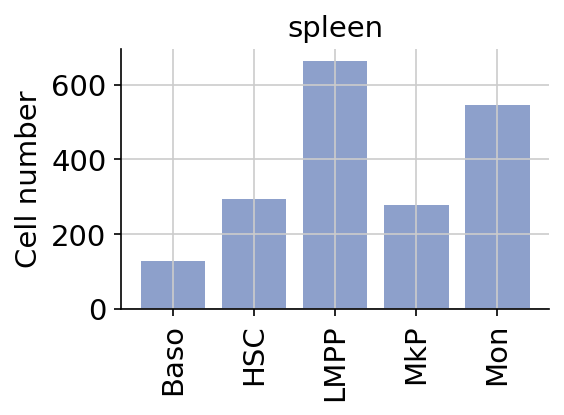

In [17]:
# Cell number per cluster
df_cell_N = (
    adata.obs[['cell_type']].reset_index()
    .groupby('cell_type').size().reset_index(name='count')
)
fig, ax = plt.subplots(figsize=(4, 3))
plt.bar(df_cell_N['cell_type'], df_cell_N['count'], color='#8da0cb')
plt.xticks(rotation=90)
plt.ylabel('Cell number')
plt.title(tissue_focus)
plt.tight_layout()
plt.savefig(f'{figure_path}/{tissue_focus}_cell_number_per_cluster.pdf')

## 9. Clone output heatmap

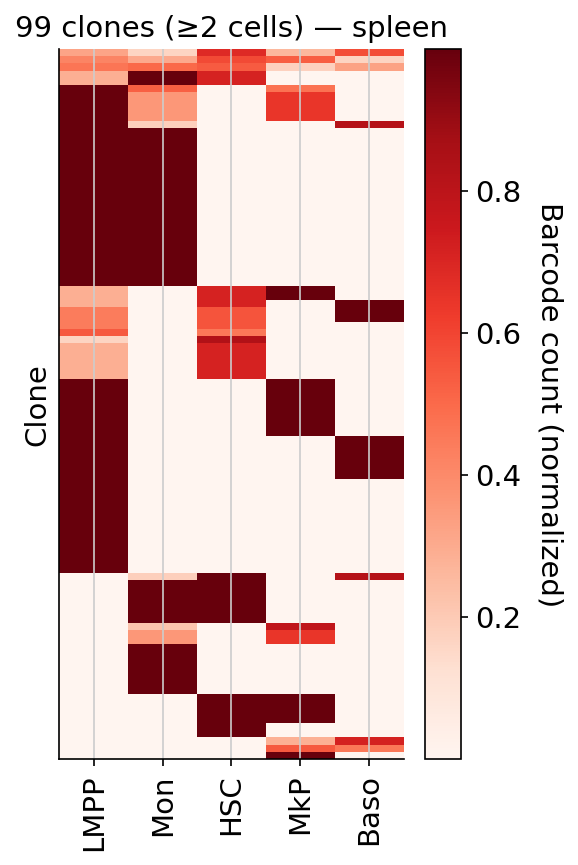

In [18]:
# Filter to clones with ≥2 cells
if 'clone_id' in adata.uns:
    del adata.uns['clone_id']
cs.tl.filter_clones(adata, clone_size_threshold=2, filter_larger_clones=False)
n_clones_2 = int(np.sum((adata.obsm['X_clone'].sum(0) > 0).A.flatten()))

selected_fates = [ct for ct in adata.obs['cell_type'].unique()
                  if ct != 'Unknown']
cs.pl.barcode_heatmap(adata, selected_fates=selected_fates, normalize=True)
plt.ylabel('Clone')
plt.title(f'{n_clones_2} clones (≥2 cells) — {tissue_focus}')
plt.tight_layout()
plt.savefig(f'{figure_path}/{tissue_focus}_clone_heatmap_ge2.pdf')

## 10. Clonal fate coupling

/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/tool/_map.py:383: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["time_info"] = pd.Categorical(adata.obs["time_info"].astype(str))
/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/help_functions/_help_functions_CoSpar.py:1155: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["available_map"] = available_map
100%|██████████| 100/100 [00:02<00:00, 46.67it/s]


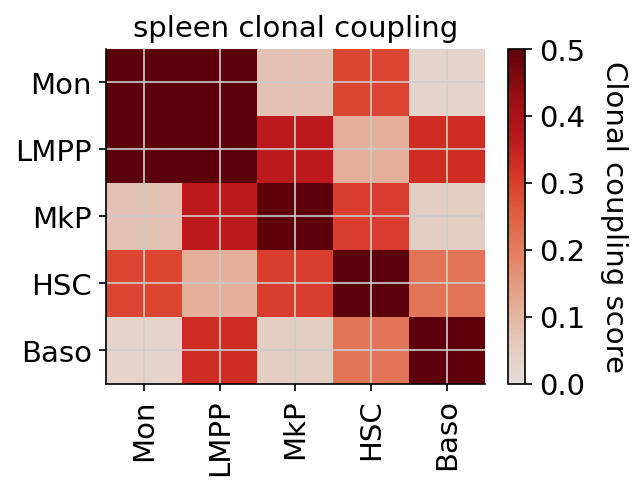

In [19]:
adata_out, X_coupling_random = cs.tl.pvalue_for_fate_coupling(
    adata, selected_fates=selected_fates,
    max_N_simutation=100, normalize=True
)

cs.pl.fate_coupling(
    adata_out, source='X_clone', vmax=0.5, vmin=0,
    title=f'{tissue_focus} clonal coupling'
)
plt.tight_layout()
plt.savefig(f'{figure_path}/{tissue_focus}_fate_coupling.pdf')

## 11. CoSpar — transition map inference

Only run if ≥2 t0 cells with clonal labels exist.

In [20]:
n_t0_clonal = int(
    (adata.obs['time_info'] == 't0').sum()
)
print(f't0 cells: {n_t0_clonal}')

if n_t0_clonal >= 10:
    adata_cs = cs.tmap.infer_Tmap_from_multitime_clones(
        adata,
        clonal_time_points=['t0'],
        later_time_point='t1',
        smooth_array=[10, 10, 5],
        sparsity_threshold=0.1,
        intraclone_threshold=0.2,
        max_iter_N=10,
        epsilon_converge=0.01,
    )
else:
    print('Too few t0 clonal cells for CoSpar — skipping transition map inference.')
    adata_cs = None

t0 cells: 956


/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/tmap/map_reconstruction.py:244: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["data_des"] = [data_des_orig, data_des]


/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/tool/_utils.py:235: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state_annote[cell_id_t2] == yy
/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/tool/_utils.py:235: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state_annote[cell_id_t2] == yy
/dfs9/ucightf-lab/kstachel/TOOLS/snakemake_DARLIN/cospar/cospar/tool/_utils.py:235: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `s

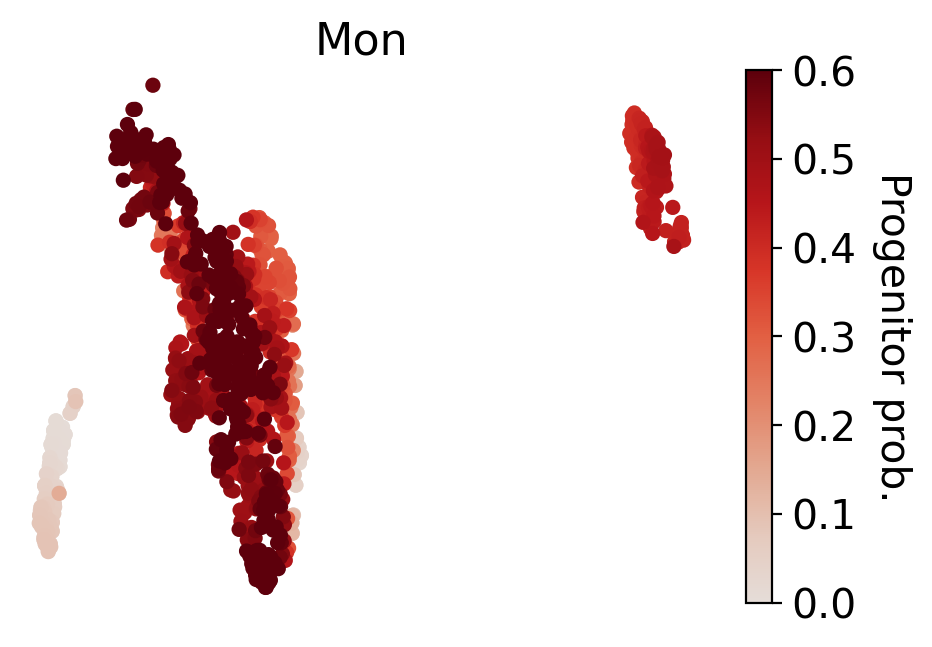

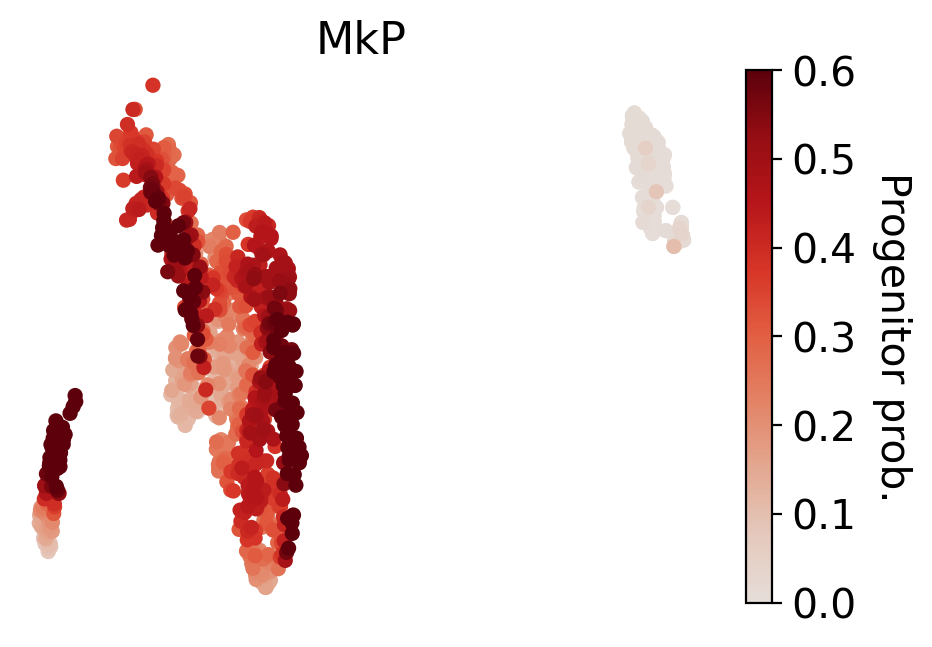

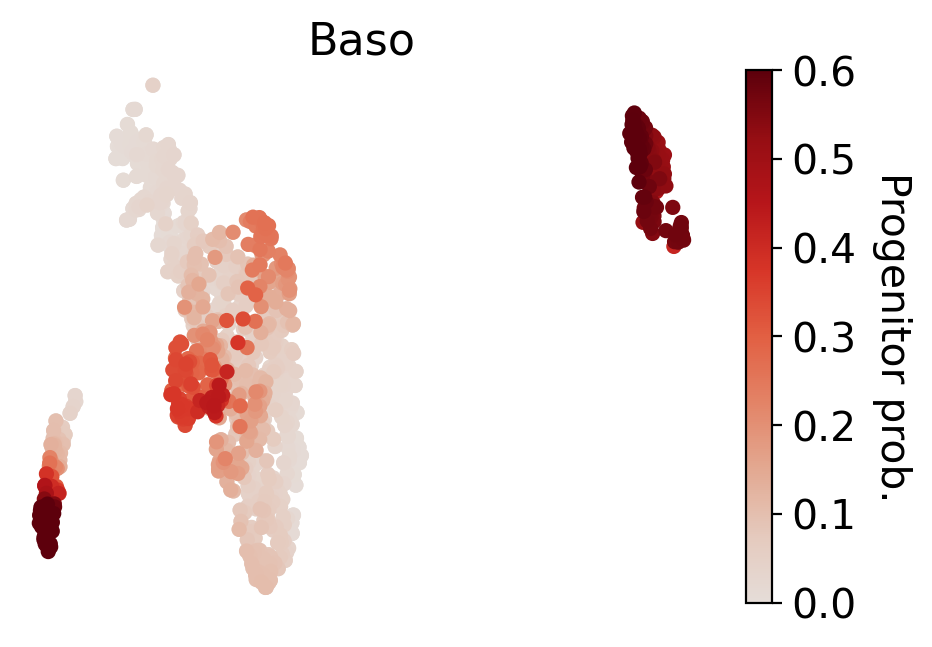

In [21]:
if adata_cs is not None:
    cs.settings.set_figure_params(pointsize=20, fontsize=16)
    for fate in selected_fates:
        if fate in ['HSC', 'LMPP']:
            continue  # skip progenitors as targets
        cs.tl.fate_map(
            adata_cs, selected_fates=[fate],
            source='transition_map', map_backward=True
        )
        cs.pl.fate_map(
            adata_cs, selected_fates=[fate],
            selected_times='t0', source='transition_map',
            plot_target_state=False, background=False,
            show_histogram=False, auto_color_scale=False, vmax=0.6
        )

## 12. Multi-tissue comparison — clone overlap

In [39]:
if len(adatas_integrated) == 2:
    t_a, t_b = list(adatas_integrated.keys())
    clones_a = set(darlin_per_cell[t_a]['joint_clone_id'].dropna().unique())
    clones_b = set(darlin_per_cell[t_b]['joint_clone_id'].dropna().unique())
    shared = clones_a & clones_b
    print(f'{t_a} joint clones: {len(clones_a)}')
    print(f'{t_b} joint clones: {len(clones_b)}')
    print(f'Shared joint clones: {len(shared)}')

    try:
        from matplotlib_venn import venn2
        fig, ax = plt.subplots(figsize=(4, 4))
        venn2([clones_a, clones_b], set_labels=(t_a, t_b))
        plt.title('Shared DARLIN joint clones (all loci)')
        plt.tight_layout()
        plt.savefig(f'{figure_path}/joint_clone_overlap_{t_a}_{t_b}.pdf')
    except ImportError:
        print('Install matplotlib-venn for Venn diagram: pip install matplotlib-venn')
else:
    print('Need exactly 2 tissues for comparison; have:', list(adatas_integrated.keys()))

Need exactly 2 tissues for comparison; have: ['lung', 'liver', 'spleen']


## 13. Save integrated objects

In [ ]:
for tissue, adata in adatas_integrated.items():
    out_path = f'data/{tissue}_darlin_integrated.h5ad'
    adata.write_h5ad(out_path)
    print(f'Saved: {out_path}')